# Task 3: Physical Performance
## Analytic Task Overview
**Analytic question formulation:**
Is there a significant difference in the average distance covered per 90 minutes between midfielders and defenders who played in the FIFA World Cup 2026? Players must have completed at least 90 minutes and have valid distance and playing-time records.

**Data wrangling:**
Player details, Total Distance and Minutes Played were obtained from FIFA's official player-statistics page using Python. Because the two variables appeared in separate FIFA tables, they were collected separately, extracted from the structured data supplied to the browser and organised into pandas DataFrames
( Fédération Internationale de Football Association [FIFA], 2026; McKinney, 2010; Microsoft, n.d.-b, n.d.-c).

The two DataFrames were merged using FIFA's unique `PlayerID`. An inner join retained players who had both Total Distance value and Minutes Played value (Charles Darwin University [CDU], 2026a; pandas development team, n.d.-a, n.d.-b).

**Data preparation and sampling:**
Records were checked for missing values and duplicate player identifiers. Total Distance was concerted from metres to kilometres, and each player's distance covered per 90 minutes was calculated usiing:

**Distance per 90 = (Total distance covered / Minutes played) * 90**
Separate simple random samples of 40 eligible players per group were selected using random_state = 140, which makes the selection reproducible when the same ordered data and preparation steps are used (pandas development team, nd.-f).

**Descriptive statistics:**
The two samples were summarised using the mean, median, standard deviation, minimum, maximum and quartiles. Boxplots, histograms and individual-player plots were used to compare their centre, spreads and distributions (National Institute of Standards and Technology [NIST], 2012; pandas development team, n.d.-b).

**Inferential statistics:**
A 95% Welch confidence interval was calculated for the difference between the population means `(MF - DF)`

A two-sided Welch independent-samples t-test then assessed whether the observed difference was statistically distinguishable from zero. Welch's method is suitable for independent samples and does not require the two population variances to be equal (Charles Darwin University, 2026d; SciPy community, n.d.-a; Welch 1947).


**Variables**
The quantitative variable is **distance covered per 90 minutes**

The categorical variable is **player position**, whith midfielders (MF) and defenders (DF) used as the two groups.

The unit of analysis is **one player**.

# Preparing Google Colab for browser collection
The next cell prepares Colab, we install Chrome, Playwright and Xvfb for the current session.

`%%writefile` is used to save the complete cell as a pythin script (IPython Development Team, n.d.)

Collab normally runs without a desktop screen, so Xvfb creates a temporary virtual display so that Chrome can run in headed mode.

Tutorials used
https://ipython.readthedocs.io/en/stable/interactive/magics.html

https://manpages.ubuntu.com/manpages/noble/man1/xvfb-run.1.html

https://playwright.dev/python/docs/intro

In [6]:
# Installs the browser tools used for data collection. See Microsoft (n.d.-a, n.d.-b)
# These commands prepare Colab environment;
!apt-get update -qq
!apt-get install -y xvfb wget

!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y ./google-chrome-stable_current_amd64.deb

!pip install -q playwright

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
wget is already the newest version (1.21.2-2ubuntu1.5).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 86 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of './google-chrome-stable_current_amd64.deb'
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schema

In [7]:
# Libraries used for browser automation, tabular data, statistics and charts.
# Method sources: Mckinney (210), Microsoft (n.d.-a, n.d.-b), pandas development team (n.d.-b),
# Matplotlib development team (n.d.) and SciPy community (n.d.).
import asyncio
import json
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from scipy import stats

## Data Wrangling
The data for this task were obtained from the official FIFA World Cup 2026 Statistics website (FIFA, 2026).

The FIFA statistics page is dynamically rendered: The browser loads the page and then recieved the player statistics through network requests.

Playwright was used becauce it can monitor browser request and response traffic. (Microsoft, n.d.-a, n.d-b).

Chrome fist opens the real FIFA page. The code observes the page's network traffic, obtains the FIFA access token and requests paginated JSON records.

It uses Playwright which controls a browser.
The browser steps use async/await because of network responses take time and we make use of asyncio which starts the program asycnchronously (Python Software Foundation, n.d.-a; Microsoft, n.d.-d).

Tutorials used
https://docs.python.org/3/library/asyncio.html

https://playwright.dev/python/docs/intro

https://playwright.dev/python/docs/network

In [8]:
%%writefile fifa_real_browser.py

import asyncio
import json
from playwright.async_api import async_playwright

# FIFA (2026) is the primary data source. Playwright's documented network events allow
# Python to observe the responses loaded by a dynamic webpage (Microsoft, n.d.-b).

FIFA_URL = ("https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics?group=gcp_physical&stat=total_distance")

async def main():
  async with async_playwright() as p:
    # Playwright's BrowserType.launch() supports the execulable_path,
    # headless and args options used below (Microsoft, n.d.-a).

    # Use the Google Chrome installed in Colab,
    # and run it in HEADED mode.
    browser = await p.chromium.launch(
        executable_path="/usr/bin/google-chrome",
        headless=False,
        args=["--no-sandbox", "--disable-dev-shm-usage", "--window-size=1440,1200"]
    )

    context = await browser.new_context(
        viewport={"width": 1440, "height": 1200},
        locale="en-AU"
    )

    page = await context.new_page()

    successful = []
    failed = []

    # Watch real GameDay responses
    # page.on('response', ...) follows Playwright's network-event approach
    # documented by Microsoft (n.d.-b).
    async def response_handler(response):
      if "gameday-prod.fifa.mangodev.co.uk" in response.url:
        print("\nGAMEDAY RESPONSE")
        print("Status:", response.status)
        print("URL:", response.url)

        if response.status == 200:
          successful.append(response.url)

          try:
            data = await response.json()

            if isinstance(data, dict):
              print("JSON keys:", list(data.keys()))

          except Exception as e:
            print("JSON read error:", e)

    # Check for failures
    async def failure_handler(request):
      if "gameday-prod.fifa.mangodev.co.uk" in request.url:
        failed.append(request.url)
        print("\nGAMEDAY FAILED")
        print("URL:", request.url)
        print("Reason:", request.failure)

    page.on("response", response_handler)
    page.on("requestfailed", failure_handler)

    print("Opening FIFA...")

    response = await page.goto(FIFA_URL, wait_until="domcontentloaded", timeout=90000)

    print("\nFIFA page status:", response.status)

    # Give FIFA's JS plenty of time
    await page.wait_for_timeout(20000)

    print("\nSUMMARY")
    print("Successful requests:", len(successful))
    print("Failed requests:", len(failed))

    await browser.close()

asyncio.run(main())

Overwriting fifa_real_browser.py


In [10]:
!xvfb-run -a python fifa_real_browser.py

Opening FIFA...

FIFA page status: 200

GAMEDAY RESPONSE
Status: 200
URL: https://gameday-prod.fifa.mangodev.co.uk/1-0/stories?query=(and%20resourceStatus==`urn:gd:resourceStatus:active`%20_externalId~`urn:gd:story:classification:gcp_physical:competitionId:285023:total_distance:rank_asc:page:1$`)&skip=0&limit=1&sort=tags.name==urn:gd:tag:story:fifa:column_number:asc
JSON keys: ['matchCount', 'index', 'requestCount', 'count', 'anotherPage', 'nextPageUrl', 'items']

GAMEDAY RESPONSE
Status: 200
URL: https://gameday-prod.fifa.mangodev.co.uk/1-0/teams?query=_externalCompetitionId==`285023`
JSON keys: ['matchCount', 'index', 'requestCount', 'count', 'anotherPage', 'nextPageUrl', 'items']

SUMMARY
Successful requests: 2
Failed requests: 0


# Manual Inspection to automated request

The FIFA-specific address and labels in the next script were identified manually examining how the FIFA site behaved.

1. Open the FIFA page in Chrome
2. Open Developer tools -> Network and reload the page
3. Filter the network list for Fetch/XHR requests.
4. Change the statistics category and page number on the FIFA site.
5. Compare the request URL, query, headers and JSON response.
6. Record which parts stayed fixed and which part changed number.

Tutorials used:
https://playwright.dev/python/docs/evaluating

https://developer.mozilla.org/en-US/docs/Web/API/Fetch_API/Using_Fetch

https://developer.mozilla.org/en-US/docs/Web/JavaScript/Reference/Global_Objects/encodeURIComponent


### Initial dataset
After extracting the player records from the 25 collected FIFA statistics pages, the initial dataset contained
- **1,242 Total Distance records**.
- **1,231 Minutes Played records**

The two JSON was tramsformed into separate pandas DataFrame so each row represents one player and each column represents one variable (McKinney, 2010; pandas development team, n.d.-b).

The extracted variables from Total Distance were:
- `PlayerID` - FIFA player identifier
- `Player` - player name
- `Team` - national team
- `TeamAbbreviation` - three-letter team abbreviation
- `Position` - player position
- `AverageSpeed` - avergae speed
- `HighSpeedRuns` - number of high-speed runs
- `Sprints` - number of sprints
- `TotalDistance` - total distance covered in metres
- `DistanceRank`- player's rank in the FIFA Total Distance statistics

The extracted variables from Minutes Played were:
- `PlayerID` - FIFA player identifier
- `Player` - player name
- `Team` - national team
- `Position` - player position
- `MinutesPlayed` - total competition minutes played
- `MinutesRank`- player's rank in the FIFA Minutes Played statistics

The two DataFrames were later merged using PlayerID. An inner join retained the 1,231 players who had recorded in both datasets (Charles Darwin University [CDU], 2026a; pandas development team, n.d.-a, n.d-b).

In [14]:
%%writefile fifa_collect_total_distance.py

import asyncio
import json
from playwright.async_api import async_playwright
from pathlib import Path

# FIFA (2026) is the primary data source. The collection method uses Playwright's documented
# page.evaluate() and network capabilities (Microsoft, n.d.-b).

FIFA_URL = ("https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics")

async def main():
  async with async_playwright() as p:
     # Playwright's BrowserType.launch() supports the execulable_path,
    # headless and args options used below (Microsoft, n.d.-a).

    # Use the Google Chrome installed in Colab,
    # and run it in HEADED mode.
    browser = await p.chromium.launch(
        executable_path="/usr/bin/google-chrome",
        headless=False,
        args=["--no-sandbox", "--disable-dev-shm-usage", "--window-size=1440,1200"]
    )

    context = await browser.new_context(
        viewport={"width": 1440, "height": 1200},
        locale="en-AU"
    )

    page = await context.new_page()

    print("Opening FIFA...")

    response = await page.goto(FIFA_URL, wait_until="domcontentloaded", timeout=90000)

    print("\nFIFA page status:", response.status)

    # Give FIFA's JS plenty of time
    await page.wait_for_timeout(12000)

    # Get token using FIFA's own token endpoint
    # page.evaluate() runs JS in the webpage context and returns its result to Python (Microsoft, n.d.-a).
    token = await page.evaluate("""
    async () => {
      const response = await fetch("https://cxm-api.fifa.com/fifaplusweb/api/external/gameDay/token");
      const data = await response.json();
      return data.token;
    }
    """)

    print("Token obtained")

    # Manual inspection of the FIFA passing table showed 25 pages at the time of collection.
    # The page number also appeared within the request query (FIFA, 2026; Microsoft, n.d.-c).
    # EncodedURIComponent() was applied because the query contains spaces, colons,
    # backticks and other characters that must be safely included in a URL (Mozilla, n.d.-a),
    all_pages = []
    for page_number in range (1, 26):
      print(f"Collecting Total Distance page {page_number}...")
      result = await page.evaluate(
        """
        async ({token, pageNumber}) => {
          const query =
            "(and resourceStatus==`urn:gd:resourceStatus:active` " +
            "_externalId~`urn:gd:story:classification:" +
            "gcp_physical:" +
            "competitionId:285023:" +
            "total_distance:" +
            "rank_asc:" +
            "page:" + pageNumber + "$`)";

          const url =
            "https://gameday-prod.fifa.mangodev.co.uk/1-0/stories" +
            "?query=" + encodeURIComponent(query) +
            "&skip=0" +
            "&limit=1" +
            "&sort=" +
            encodeURIComponent(
                "tags.name==urn:gd:tag:story:fifa:column_number:asc"
            );

          const response = await fetch(
              url,
              {
                headers: {
                  "Authorization": "Bearer " + token,
                  "Accept": "application/json, text/plain, */*"
                }
              }
            );

            const text = await response.text();

            return {
                status: response.status,
                url: url,
                text: text
            };
        }
        """,
        {"token": token, "pageNumber": page_number}
      )

      print("Status:", result["status"])

      if result["status"] != 200:
        print("Stopped because page", page_number, "returned", result["status"])
        print(result["text"][:500])
        break

      data = json.loads(result["text"])

      all_pages.append({"page_number": page_number, "url": result["url"], "data": data})

      # Although manual inspection found 25 pages,
      # Stop early if FIFA returns a page containing no player records
      items = data.get("items", [])
      if not items:
        print("No items returned")
        break

  # Save FIFA JSON
  Path("fifa_total_distance_raw.json").write_text(
      json.dumps(all_pages, indent=2, ensure_ascii=False), encoding="utf-8"
  )

  print("\nCOLLECTION COMPLETE")
  print("Pages captured:", len(all_pages))
  print("Saved: fifa_total_distance_raw.json")

  await browser.close()

asyncio.run(main())

Writing fifa_collect_total_distance.py


In [15]:
!xvfb-run -a python fifa_collect_total_distance.py

Opening FIFA...

FIFA page status: 200
Token obtained
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200

COLLECTION COMPLETE
Pages captured: 25
Saved: fifa_total_distance_raw.json


In [16]:
# Load the raw FIFA Total Distance JSON
with open("fifa_total_distance_raw.json", "r", encoding="utf-8") as file:
    raw_distance_pages = json.load(file)

print("Pages loaded:", len(raw_distance_pages))

Pages loaded: 25


In [17]:
# Inspect one representative page
first_page = raw_distance_pages[0]["data"]

print(first_page.keys())
print("Number of story items:", len(first_page["items"]))

dict_keys(['matchCount', 'index', 'requestCount', 'count', 'anotherPage', 'nextPageUrl', 'items'])
Number of story items: 1


In [18]:
# Examone the structure of a FIFA story
story = first_page["items"][0]
print(story.keys())

dict_keys(['_id', '_externalId', '_externalIdScope', 'classification', 'shortName', 'name', 'shortDescription', 'longDescription', 'actors', 'sidecar', 'resourceType', 'resourceStatus', 'sportType', 'defaultLanguage', 'documents', 'audios', 'videos', 'images', 'tags', 'createdAt', 'updatedAt'])


In [19]:
# Access the first player record
print(json.dumps(story["actors"][0], indent=2)[:8000])

{
  "key": {
    "keyType": "staff",
    "_externalTeamId": "285023_43969",
    "_externalTeamIdScope": "fifa",
    "_externalSportsPersonId": "411375",
    "_externalSportsPersonIdScope": "fifa"
  },
  "number": 1,
  "name": {
    "eng": "Rodri",
    "spa": "Rodri",
    "fra": "Rodri",
    "deu": "Rodri",
    "ara": "\u0631\u0648\u062f\u0631\u064a",
    "por": "Rodri",
    "jpn": "\u30ed\u30c9\u30ea",
    "ita": "Rodri",
    "kor": "\ub85c\ub4dc\ub9ac",
    "ind": "Rodri",
    "rus": "\u0420\u043e\u0434\u0440\u0438"
  },
  "tags": [
    {
      "name": "urn:gd:tag:story:actor:default_language",
      "value": "eng"
    },
    {
      "name": "urn:gd:tag:story:background_colour",
      "value": "FF0000"
    },
    {
      "name": "urn:gd:tag:story:foreground_colour",
      "value": "000000"
    },
    {
      "name": "urn:gd:tag:story:staff:display_name:ara",
      "value": "\u0631\u0648\u062f\u0631\u064a"
    },
    {
      "name": "urn:gd:tag:story:staff:display_name:deu",
      "val

In [20]:
# Display the name and value of each tag
for tag in story["actors"][0].get("tags", []):

    print(tag.get("name"), "=", tag.get("value"))

urn:gd:tag:story:actor:default_language = eng
urn:gd:tag:story:background_colour = FF0000
urn:gd:tag:story:foreground_colour = 000000
urn:gd:tag:story:staff:display_name:ara = رودري
urn:gd:tag:story:staff:display_name:deu = Rodri
urn:gd:tag:story:staff:display_name:eng = Rodri
urn:gd:tag:story:staff:display_name:fra = Rodri
urn:gd:tag:story:staff:display_name:ind = Rodri
urn:gd:tag:story:staff:display_name:ita = Rodri
urn:gd:tag:story:staff:display_name:jpn = ロドリ
urn:gd:tag:story:staff:display_name:kor = 로드리
urn:gd:tag:story:staff:display_name:por = Rodri
urn:gd:tag:story:staff:display_name:rus = Родри
urn:gd:tag:story:staff:display_name:spa = Rodri
urn:gd:tag:story:staff:display_name:zho = Rodri
urn:gd:tag:story:staff:gender:fdh = m
urn:gd:tag:story:staff:image = https://digitalhub.fifa.com/transform/295ab5b2-4dbf-42b9-918b-04fb4ae0ec0a/RODRI_411375
urn:gd:tag:story:staff:match_squad:included = True
urn:gd:tag:story:staff:match_squad:match_id = ['151649', '151651', '151653', '151690',

In [28]:
%%writefile fifa_minutes_browser.py

import asyncio
import json
from playwright.async_api import async_playwright

# FIFA (2026) is the primary data source. Playwright's documented network events allow
# Python to observe the responses loaded by a dynamic webpage (Microsoft, n.d.-b).

FIFA_URL = ("https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics?group=gcp_top_scorer&stat=total_competition_minutes_played")

async def main():
  async with async_playwright() as p:
    # Playwright's BrowserType.launch() supports the execulable_path,
    # headless and args options used below (Microsoft, n.d.-a).

    # Use the Google Chrome installed in Colab,
    # and run it in HEADED mode.
    browser = await p.chromium.launch(
        executable_path="/usr/bin/google-chrome",
        headless=False,
        args=["--no-sandbox", "--disable-dev-shm-usage", "--window-size=1440,1200"]
    )

    context = await browser.new_context(
        viewport={"width": 1440, "height": 1200},
        locale="en-AU"
    )

    page = await context.new_page()

    successful = []
    failed = []

    # Watch real GameDay responses
    # page.on('response', ...) follows Playwright's network-event approach
    # documented by Microsoft (n.d.-b).
    async def response_handler(response):
      if "gameday-prod.fifa.mangodev.co.uk" in response.url:
        print("\nGAMEDAY RESPONSE")
        print("Status:", response.status)
        print("URL:", response.url)

        if response.status == 200:
          successful.append(response.url)

          try:
            data = await response.json()

            if isinstance(data, dict):
              print("JSON keys:", list(data.keys()))

          except Exception as e:
            print("JSON read error:", e)

    # Check for failures
    async def failure_handler(request):
      if "gameday-prod.fifa.mangodev.co.uk" in request.url:
        failed.append(request.url)
        print("\nGAMEDAY FAILED")
        print("URL:", request.url)
        print("Reason:", request.failure)

    page.on("response", response_handler)
    page.on("requestfailed", failure_handler)

    print("Opening FIFA...")

    response = await page.goto(FIFA_URL, wait_until="domcontentloaded", timeout=90000)

    print("\nFIFA page status:", response.status)

    # Give FIFA's JS plenty of time
    await page.wait_for_timeout(20000)

    print("\nSUMMARY")
    print("Successful requests:", len(successful))
    print("Failed requests:", len(failed))

    await browser.close()

asyncio.run(main())

Overwriting fifa_minutes_browser.py


In [29]:
!xvfb-run -a python fifa_minutes_browser.py

Opening FIFA...

FIFA page status: 200

GAMEDAY RESPONSE
Status: 200
URL: https://gameday-prod.fifa.mangodev.co.uk/1-0/teams?query=_externalCompetitionId==`285023`

GAMEDAY RESPONSE
Status: 200
URL: https://gameday-prod.fifa.mangodev.co.uk/1-0/stories?query=(and%20resourceStatus==`urn:gd:resourceStatus:active`%20_externalId~`urn:gd:story:classification:gcp_top_scorer:competitionId:285023:total_competition_minutes_played:rank_asc:page:1$`)&skip=0&limit=1&sort=tags.name==urn:gd:tag:story:fifa:column_number:asc
JSON keys: ['matchCount', 'index', 'requestCount', 'count', 'anotherPage', 'nextPageUrl', 'items']
JSON keys: ['matchCount', 'index', 'requestCount', 'count', 'anotherPage', 'nextPageUrl', 'items']

SUMMARY
Successful requests: 2
Failed requests: 0


In [55]:
%%writefile fifa_collect_minutes.py

import asyncio
import json
from playwright.async_api import async_playwright
from pathlib import Path

# FIFA (2026) is the primary data source. The collection method uses Playwright's documented
# page.evaluate() and network capabilities (Microsoft, n.d.-b).

FIFA_URL = ("https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics?group=gcp_top_scorer&stat=total_competition_minutes_played")

async def main():
  async with async_playwright() as p:
     # Playwright's BrowserType.launch() supports the execulable_path,
    # headless and args options used below (Microsoft, n.d.-a).

    # Use the Google Chrome installed in Colab,
    # and run it in HEADED mode.
    browser = await p.chromium.launch(
        executable_path="/usr/bin/google-chrome",
        headless=False,
        args=["--no-sandbox", "--disable-dev-shm-usage", "--window-size=1440,1200"]
    )

    context = await browser.new_context(
        viewport={"width": 1440, "height": 1200},
        locale="en-AU"
    )

    page = await context.new_page()

    print("Opening FIFA...")

    response = await page.goto(FIFA_URL, wait_until="domcontentloaded", timeout=90000)

    print("\nFIFA page status:", response.status)

    # Give FIFA's JS plenty of time
    await page.wait_for_timeout(12000)

    # Get token using FIFA's own token endpoint
    # page.evaluate() runs JS in the webpage context and returns its result to Python (Microsoft, n.d.-a).
    token = await page.evaluate("""
    async () => {
      const response = await fetch("https://cxm-api.fifa.com/fifaplusweb/api/external/gameDay/token");
      const data = await response.json();
      return data.token;
    }
    """)

    print("Token obtained")

    # Manual inspection of the FIFA passing table showed 25 pages at the time of collection.
    # The page number also appeared within the request query (FIFA, 2026; Microsoft, n.d.-c).
    # EncodedURIComponent() was applied because the query contains spaces, colons,
    # backticks and other characters that must be safely included in a URL (Mozilla, n.d.-a),
    all_pages = []
    for page_number in range (1, 26):
      print(f"Collecting Minutes Played page {page_number}...")
      result = await page.evaluate(
        """
        async ({token, pageNumber}) => {
          const query =
            "(and resourceStatus==`urn:gd:resourceStatus:active` " +
            "_externalId~`urn:gd:story:classification:" +
            "gcp_top_scorer:" +
            "competitionId:285023:" +
            "total_competition_minutes_played:" +
            "rank_asc:" +
            "page:" + pageNumber + "$`)";

          const url =
            "https://gameday-prod.fifa.mangodev.co.uk/1-0/stories" +
            "?query=" + encodeURIComponent(query) +
            "&skip=0" +
            "&limit=1" +
            "&sort=" +
            encodeURIComponent(
                "tags.name==urn:gd:tag:story:fifa:column_number:asc"
            );

          const response = await fetch(
              url,
              {
                headers: {
                  "Authorization": "Bearer " + token,
                  "Accept": "application/json, text/plain, */*"
                }
              }
            );

            const text = await response.text();

            return {
                status: response.status,
                url: url,
                text: text
            };
        }
        """,
        {"token": token, "pageNumber": page_number}
      )

      print("Status:", result["status"])

      if result["status"] != 200:
        print("Stopped because page", page_number, "returned", result["status"])
        print(result["text"][:500])
        break

      data = json.loads(result["text"])

      all_pages.append({"page_number": page_number, "url": result["url"], "data": data})

      # Although manual inspection found 25 pages,
      # Stop early if FIFA returns a page containing no player records
      items = data.get("items", [])
      if not items:
        print("No items returned")
        break

  # Save FIFA JSON
  Path("fifa_minutes_raw.json").write_text(
      json.dumps(all_pages, indent=2, ensure_ascii=False), encoding="utf-8"
  )

  print("\nCOLLECTION COMPLETE")
  print("Pages captured:", len(all_pages))
  print("Saved: fifa_minutes_raw.json")

  await browser.close()

asyncio.run(main())

Overwriting fifa_collect_minutes.py


In [56]:
!xvfb-run -a python fifa_collect_minutes.py

Opening FIFA...

FIFA page status: 200
Token obtained
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200

COLLECTION COMPLETE
Pages captured: 25
Saved: fifa_minutes_raw.json


In [57]:
# Load the raw FIFA Minutes Played JSON
with open(
    "fifa_minutes_raw.json",
    "r",
    encoding="utf-8"
) as file:
    raw_minutes_pages = json.load(file)

print("Pages loaded:", len(raw_minutes_pages))

Pages loaded: 25


In [58]:
# Access the first player from the first page
first_minutes_page = raw_minutes_pages[0]["data"]

minutes_story = first_minutes_page["items"][0]

first_minutes_player = minutes_story["actors"][0]

print("Player:", first_minutes_player["name"]["eng"])

Player: Emiliano Martinez


In [59]:
# Display the statistics, position and team tags
for tag in first_minutes_player.get("tags", []):

    tag_name = tag.get("name")

    if (
        "football:stats" in tag_name
        or "staff:position" in tag_name
        or "team:name:eng" in tag_name
        or "team:abbreviation" in tag_name
        or "staff:rank" in tag_name
    ):

        print(tag_name, "=", tag.get("value"))

urn:gd:tag:story:team:abbreviation = ARG
urn:gd:tag:story:team:name:eng = Argentina
urn:gd:tag:football:stats:goals = 0
urn:gd:tag:football:stats:assists = 0
urn:gd:tag:football:stats:total_competition_minutes_played = 934
urn:gd:tag:football:stats:fdcp_top_scorer_rank = 1302
urn:gd:tag:story:staff:position = GK
urn:gd:tag:story:staff:position:eng = GK
urn:gd:tag:story:staff:position:description:eng = Goalkeeper
urn:gd:tag:story:staff:position:description:spa = Arquero
urn:gd:tag:story:staff:position:description:fra = Gardien de but
urn:gd:tag:story:staff:position:description:deu = Torhüter
urn:gd:tag:story:staff:position:description:ara = حارس مرمى
urn:gd:tag:story:staff:position:description:por = Goleiro
urn:gd:tag:story:staff:position:description:jpn = ゴールキーパー
urn:gd:tag:story:staff:position:description:ita = Portiere
urn:gd:tag:story:staff:position:description:kor = 골키퍼
urn:gd:tag:story:staff:position:description:ind = Penjaga Gawang
urn:gd:tag:story:staff:rank = 1302


In [60]:
# Convert a player's tags into a simple dictionary
def get_tags(actor):
    return {
        tag["name"]: tag["value"]
        for tag in actor.get("tags", [])
    }

In [61]:
distance_players = []

for page in raw_distance_pages:
  story_items = page["data"].get("items", [])
  for story in story_items:
    for actor in story.get("actors", []):
      tags = get_tags(actor)
      distance_players.append({
          "PlayerID": actor.get("key", {}).get("_externalSportsPersonId"),
          "Player": actor.get("name", {}).get("eng"),
          "Team": tags.get("urn:gd:tag:story:team:name:eng"),
          "TeamAbbreviation": tags.get("urn:gd:tag:story:team:abbreviation"),
          "Position": tags.get("urn:gd:tag:story:staff:position"),
          "AverageSpeed": tags.get("urn:gd:tag:football:stats:avg_speed"),
          "HighSpeedRuns": tags.get("urn:gd:tag:football:stats:speed_runs"),
          "Sprints": tags.get("urn:gd:tag:football:stats:sprints"),
          "TotalDistance": tags.get("urn:gd:tag:football:stats:total_distance"),
          "DistanceRank": tags.get("urn:gd:tag:story:staff:rank")
      })
distance_df = pd.DataFrame(distance_players)
distance_df.head()


,PlayerID,Player,Team,TeamAbbreviation,Position,AverageSpeed,HighSpeedRuns,Sprints,TotalDistance,DistanceRank
0,411375,Rodri,Spain,ESP,MF,7.05,1294,318,96233.71,1
1,430628,Alexis Mac Allister,Argentina,ARG,MF,6.23,1024,277,90561.77,2
2,430735,Marc Cucurella,Spain,ESP,DF,6.18,907,363,87986.05,3
3,474973,Pau Cubarsi,Spain,ESP,DF,6.03,816,263,85956.03,4
4,485655,Michael Olise,France,FRA,FW,7.07,1054,388,84499.58,5


In [62]:
minutes_players = []

for page in raw_minutes_pages:
  story_items = page["data"].get("items", [])
  for story in story_items:
    for actor in story.get("actors", []):
      tags = get_tags(actor)
      minutes_players.append({
          "PlayerID": actor.get("key", {}).get("_externalSportsPersonId"),
          "Player": actor.get("name", {}).get("eng"),
          "Team": tags.get("urn:gd:tag:story:team:name:eng"),
          "Position": tags.get("urn:gd:tag:story:staff:position"),
          "MinutesPlayed": tags.get("urn:gd:tag:football:stats:total_competition_minutes_played"),
          "MinutesRank": tags.get("urn:gd:tag:story:staff:rank")
      })

minutes_df = pd.DataFrame(minutes_players)
minutes_df.head()

,PlayerID,Player,Team,Position,MinutesPlayed,MinutesRank
0,308300,Emiliano Martinez,Argentina,GK,934,1302
1,430628,Alexis Mac Allister,Argentina,MF,869,92
2,430735,Marc Cucurella,Spain,DF,857,194
3,474973,Pau Cubarsi,Spain,DF,857,1300
4,430753,Unai Simon,Spain,GK,857,1300


In [63]:
print("Total distance records:", len(distance_df))
print("Minutes played records:", len(minutes_df))

Total distance records: 1242
Minutes played records: 1231


### Data Quality Checks

Before merging the two datasets, the column types, missing values and duplicate player IDs were examined.

The player ID provided by FIFA will be used to match each player's Total Distance record with their Minutes Played record.

In [64]:
distance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1242 entries, 0 to 1241
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PlayerID          1242 non-null   object 
 1   Player            1242 non-null   object 
 2   Team              1242 non-null   object 
 3   TeamAbbreviation  1242 non-null   object 
 4   Position          1242 non-null   object 
 5   AverageSpeed      1242 non-null   float64
 6   HighSpeedRuns     1242 non-null   int64  
 7   Sprints           1242 non-null   int64  
 8   TotalDistance     1242 non-null   float64
 9   DistanceRank      1242 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 97.2+ KB


In [65]:
minutes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PlayerID       1231 non-null   object
 1   Player         1231 non-null   object
 2   Team           1231 non-null   object
 3   Position       1231 non-null   object
 4   MinutesPlayed  1231 non-null   int64 
 5   MinutesRank    1231 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 57.8+ KB


In [66]:
print(f"Total distance missing values:\n{distance_df.isna().sum()}")
print(f"\nMinutes played missing values:\n{minutes_df.isna().sum()}")

Total distance missing values:
PlayerID            0
Player              0
Team                0
TeamAbbreviation    0
Position            0
AverageSpeed        0
HighSpeedRuns       0
Sprints             0
TotalDistance       0
DistanceRank        0
dtype: int64

Minutes played missing values:
PlayerID         0
Player           0
Team             0
Position         0
MinutesPlayed    0
MinutesRank      0
dtype: int64


In [67]:
# Create sets of Player IDs from both datasets
print("Duplicate Player IDs in distance:", distance_df["PlayerID"].duplicated().sum())
print("Duplicate Player IDs in minutes:", minutes_df["PlayerID"].duplicated().sum())

Duplicate Player IDs in distance: 0
Duplicate Player IDs in minutes: 0


### Merging the FIFA Datasets

The Total Distance and Minutes Played statistics were collected from separate FIFA tables.

The two datasets were merged using `PlayerID`, which is FIFA's unique identifier for each player. An inner join was used because the calculation requires each player to have both a Total Distance value and a Minutes Played value.

Tutorial:


In [68]:
# Keep only the required column from the minutes dataset
minutes_required = minutes_df[["PlayerID", "MinutesPlayed"]]

# Merge distance and minutes using FIFA Player ID
physical_df = pd.merge(
  distance_df,
  minutes_required,
  on="PlayerID",
  how="inner"
)

physical_df.head()

,PlayerID,Player,Team,TeamAbbreviation,Position,AverageSpeed,HighSpeedRuns,Sprints,TotalDistance,DistanceRank,MinutesPlayed
0,411375,Rodri,Spain,ESP,MF,7.05,1294,318,96233.71,1,819
1,430628,Alexis Mac Allister,Argentina,ARG,MF,6.23,1024,277,90561.77,2,869
2,430735,Marc Cucurella,Spain,ESP,DF,6.18,907,363,87986.05,3,857
3,474973,Pau Cubarsi,Spain,ESP,DF,6.03,816,263,85956.03,4,857
4,485655,Michael Olise,France,FRA,FW,7.07,1054,388,84499.58,5,719


In [69]:
physical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PlayerID          1231 non-null   object 
 1   Player            1231 non-null   object 
 2   Team              1231 non-null   object 
 3   TeamAbbreviation  1231 non-null   object 
 4   Position          1231 non-null   object 
 5   AverageSpeed      1231 non-null   float64
 6   HighSpeedRuns     1231 non-null   int64  
 7   Sprints           1231 non-null   int64  
 8   TotalDistance     1231 non-null   float64
 9   DistanceRank      1231 non-null   int64  
 10  MinutesPlayed     1231 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 105.9+ KB


In [70]:
# Check wheter the FIFA player identifier appears more than once.
print("Duplicate Player IDs:", physical_df["PlayerID"].duplicated().sum())

Duplicate Player IDs: 0


### Calculating Distance Per 90 Minutes

Total Distance cannot be compared fairly without considering playing time. A player who participated in more matches would normally cover more distance simply because they spent more time on the field.

To make players more comparable, Total Distance was converted from metres to kilometres and calculated as a rate per 90 minutes:

**Distance per 90 = (Total distance in kilometres ÷ Minutes played) × 90**

In [71]:
# Covert the required variables to numeric values
physical_df["MinutesPlayed"] = pd.to_numeric(physical_df["MinutesPlayed"], errors="coerce")
physical_df["TotalDistance"] = pd.to_numeric(physical_df["TotalDistance"], errors="coerce")

print(physical_df[["MinutesPlayed", "TotalDistance"]].dtypes)

MinutesPlayed      int64
TotalDistance    float64
dtype: object


In [72]:
print("Missing Minutes Played:", physical_df["MinutesPlayed"].isna().sum())
print("Missing Total Distance:", physical_df["TotalDistance"].isna().sum())
print("Players with zero minutes:", (physical_df["MinutesPlayed"] == 0).sum())

Missing Minutes Played: 0
Missing Total Distance: 0
Players with zero minutes: 198


## Data Preparation and Sampling

For Task 3, only midfielders and defenders are required.

Players with zero recorded minutes were excluded because distance per 90 minutes cannot be calculated when a player has not played. Records with missing distance, missing minutes or missing position values were also excluded.

The effect of very low playing time will be examined before the final eligibility criteria and samples are selected.

In [73]:
# Keep only midfielders and defenders
task3_df = physical_df[physical_df["Position"].isin(["MF", "DF"])].copy()

print("Midfielder and defender records:",len(task3_df))
print(task3_df["Position"].value_counts())

Midfielder and defender records: 785
Position
DF    417
MF    368
Name: count, dtype: int64


In [77]:
# Keep players with valid minutes and distance
task3_df = task3_df[
  task3_df["MinutesPlayed"].notna()
  & task3_df["TotalDistance"].notna()
  & (task3_df["MinutesPlayed"] > 0)
  & (task3_df["TotalDistance"] >= 0)
].copy()

print("Eligible records after removing invalid values:", len(task3_df))
print(task3_df["Position"].value_counts())

Eligible records after removing invalid values: 677
Position
DF    350
MF    327
Name: count, dtype: int64


In [78]:
# Convert metres to kilometres
task3_df["TotalDistanceKm"] = (task3_df["TotalDistance"] / 1000)

# Calculate distance covered per 90 minutes
task3_df["DistancePer90"] = (task3_df["TotalDistanceKm"] / task3_df["MinutesPlayed"]) * 90

In [81]:
# Keep players who completed at least 90 minutes
task3_df = task3_df[task3_df["MinutesPlayed"] >= 90].copy()

print("Rows after filtering", len(task3_df))
print(task3_df["Position"].value_counts())

Rows after filtering 529
Position
DF    279
MF    250
Name: count, dtype: int64


In [83]:
# Set the sample size
sample_size = 40

# Use a fixed seed so the samples can be reproduced
random_seed = 140

mf_sample= task3_df[task3_df["Position"] == "MF"].sample(n=sample_size, random_state=random_seed)
df_sample = task3_df[task3_df["Position"] == "DF"].sample(n=sample_size, random_state=random_seed)

## Descriptive Statistics

Descriptive statistics are used to summarise the distance covered per 90 minutes in the two random samples.

use `DataFrame.describe()` to calculate count, mean, standard deviation, minimum quartile and maximum (pandas development team, n.d.-b).

Following statistics are calculated fro `PassingAccuracy` for each player group:
- sample size (`n`)
- mean
- median
- standard deviation
- minimum
- first quartile (`Q1`)
- third quartile (`Q3`)
- maximum

### Interpretation of descriptive statistics
Sample Mean
- Midfielder: 9.93 km/90 mins
- Defender: 9.12 km/90 mins
- Difference: 0.81 km/ 90 mins (MF-DF)

Median
- Midfielder: 9.94 km/90 mins
- Defender: 9.14 km/ 90 mins

Standard deviation
- Midfielder: 0.59 km
- Defender: 0.60 km

Quartiles
- Midfielder ranged from 9.54 km to 10.33km.
- Defender ranged from 8.76 km to 9.52 km

Minimum and Maximum (respectively)
- Midfielder (8.68 km, 11.30 km)
- Defender (7.97 km, 10.32 km)

# Boxplot use
Boxplot displays median, quartiles and spread making it easier to inspect (NIST, 2012; pandas development team, n.d.-b).

In [84]:
# Calculate descriptive statistics
mf_stats_task3 = mf_sample["DistancePer90"].describe()

df_stats_task3 = df_sample["DistancePer90"].describe()

print("Midfielders:")
print(mf_stats_task3)

print("\nDefenders:")
print(df_stats_task3)

Midfielders:
count    40.000000
mean      9.933806
std       0.591733
min       8.681270
25%       9.541273
50%       9.935877
75%      10.328288
max      11.299818
Name: DistancePer90, dtype: float64

Defenders:
count    40.000000
mean      9.119338
std       0.595595
min       7.966811
25%       8.758424
50%       9.140447
75%       9.516328
max      10.318152
Name: DistancePer90, dtype: float64


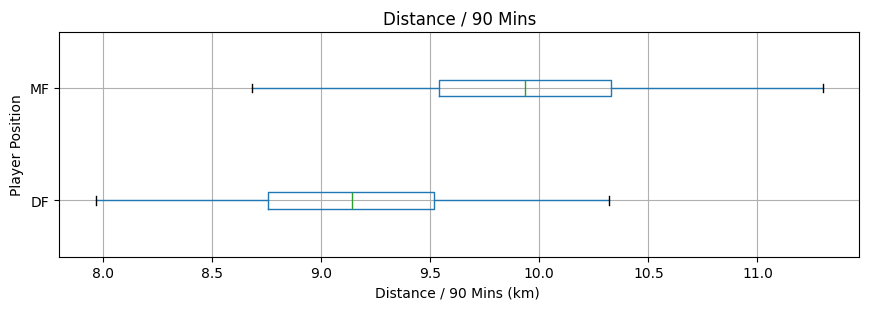

<Figure size 640x480 with 0 Axes>

In [86]:
# Combine the two samples for plotting
# Side-by-side boxplots compare group centre and spread
# (National Institute of Standards and Technology [NIST], 2012).
plot_df = pd.concat([mf_sample.assign(Group="Midfielders"),df_sample.assign(Group="Defenders")])
plot_df.boxplot(column="DistancePer90", by="Position", vert=False, figsize=(10, 3))

plt.title("Distance / 90 Mins")
plt.suptitle("")
plt.xlabel("Distance / 90 Mins (km) ")
plt.ylabel("Player Position")
plt.show()

plt.tight_layout()
plt.show()

### Visual Analysis of the Samples

Several visualisations were created to examine the distribution, overlap and composition of the data.

The histogram shows the shape of each sample distribution, while the individual-player plot displays every sampled value. The population pie chart shows the proportion of eligible midfielders and defenders before sampling.

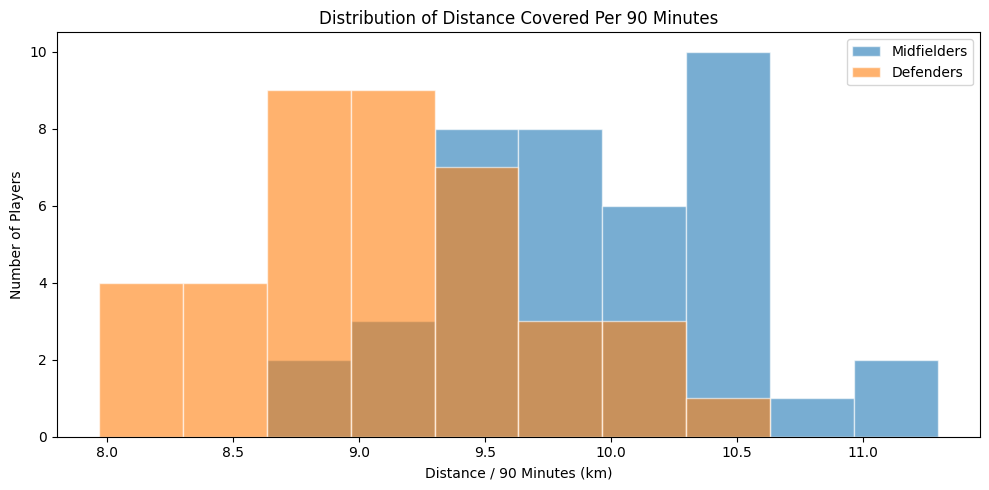

In [87]:
# Use the same histogram bins for both groups
histogram_bins = np.linspace(plot_df["DistancePer90"].min(), plot_df["DistancePer90"].max(), 11)

plt.figure(figsize=(10, 5))

plt.hist(
    mf_sample["DistancePer90"],
    bins=histogram_bins,
    alpha=0.6,
    label="Midfielders",
    edgecolor="white"
)

plt.hist(
    df_sample["DistancePer90"],
    bins=histogram_bins,
    alpha=0.6,
    label="Defenders",
    edgecolor="white"
)

plt.title("Distribution of Distance Covered Per 90 Minutes")
plt.xlabel("Distance / 90 Minutes (km)")
plt.ylabel("Number of Players")
plt.legend()
plt.tight_layout()
plt.show()

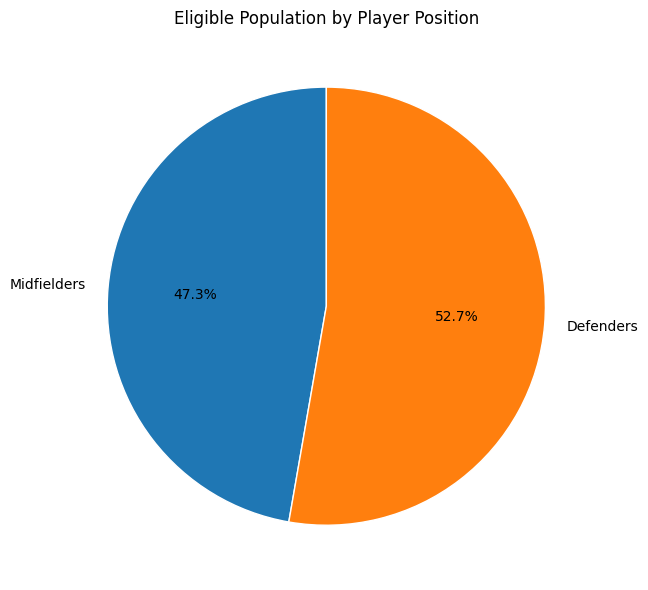

In [90]:
population_counts = task3_df["Position"].value_counts().reindex(["MF", "DF"])

plt.figure(figsize=(7, 6))

plt.pie(
    population_counts,
    labels=[
        "Midfielders",
        "Defenders"
    ],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={
        "edgecolor": "white"
    }
)

plt.title("Eligible Population by Player Position")
plt.tight_layout()
plt.show()

## Inferential Statistics - Confidence Interval
The difference between the eligible midfielder and defender population means.

95% Welch confidence interval was caluclated for the mean difference because the samples are independent and variances are not assumed to be equal(Welch, 1947).

`errorbar()` is used at zero to represent no difference (Matplotlib development team, n.d.-b).

The sample difference: 0.81 km / 90 mins (MF - DF)
95% confidence intervale: 0.55 to 1.08 km / 90 mins.

Tutorials used
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

In [93]:
# This analysis follows the CI procedures introduced in
# HIT140 Week 3 and the independent two-sample t-test introduced in Week 4
# (Charles Darwin University, 2026a, 2026b).
#
# Utilising the Welch's degrees of freedom and a 95% CI
# for the difference between the two population means (Welch, 1947).
#
# Scipy documentation was used for implementation of stats.sem(),
# stats.t.interval(), stats.t.ppf() and stats.ttest_ind()
# Passing accuracy values from the two random samples
mf_values_task3 = mf_sample["DistancePer90"]
df_values_task3 = df_sample["DistancePer90"]

# Sample sizes
mf_n_task3 = len(mf_values_task3)
df_n_task3 = len(df_values_task3)

# Sample means and variances
mf_mean_task3 = (mf_values_task3.mean())
df_mean_task3 = (df_values_task3.mean())

mf_std_task3 = (mf_values_task3.std(ddof=1))

df_std_task3 = (df_values_task3.std(ddof=1))

mean_difference_task3 = (mf_mean_task3 - df_mean_task3)

standard_error = np.sqrt((mf_std_task3 ** 2 / mf_n_task3) + (df_std_task3 ** 2 / df_n_task3))

# Calculate degree of freedom using the
# Welch-Satterthwaite equation (Satterthwaite, 1946; Welch, 1947).
welch_df = (
    (mf_std_task3 ** 2 / mf_n_task3 + df_std_task3 ** 2 / df_n_task3) ** 2 /
    (
      ((mf_std_task3 ** 2 / mf_n_task3) ** 2 / (mf_n_task3 - 1)) +
      ((df_std_task3 ** 2 / df_n_task3 ) ** 2 / (df_n_task3 - 1))
    )
)

In [94]:
# Critical t-value for a 95% confidence interval
t_critical_task3 = stats.t.ppf(0.975, welch_df)

# Margin of error
margin_error_task3 = t_critical_task3* standard_error

# Confidence interval limits
difference_ci_lower = (mean_difference_task3 - margin_error_task3)

difference_ci_upper = (mean_difference_task3 + margin_error_task3)

In [101]:
t_statistic, p_value = stats.ttest_ind(mf_values_task3, df_values_task3, equal_var=False)

In [102]:
# Display the results
print(f"Midfielder mean: {mf_mean_task3:.2f}%")
print(f"\nDefender mean: {df_mean_task3:.2f}%")

print(f"\nMean difference (MF - DF): {mean_difference_task3:.2f} percentage points")
print(f"95% CI for difference: {difference_ci_lower:.2f} to {difference_ci_upper:.2f}")
print(f"Welch degrees of freedom: {welch_df:.2f}")

print(f"\nt-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3e}")

Midfielder mean: 9.93%

Defender mean: 9.12%

Mean difference (MF - DF): 0.81 percentage points
95% CI for difference: 0.55 to 1.08
Welch degrees of freedom: 78.00

t-statistic: 6.14
p-value: 3.293e-08


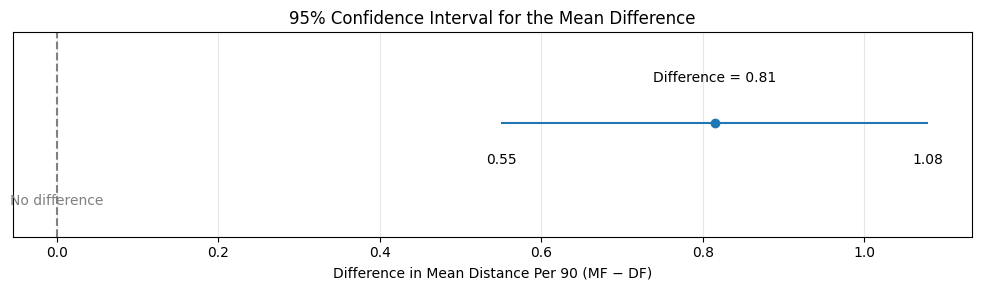

In [100]:
# Matplotlib's errorbar() displays the point estimate and confidence interval
# (Matplotlib development team, n.d.-a).
plt.figure(figsize=(10, 3))

# Draw the confidence interval and observed difference
# Requires asymmetric x-errors to be supplied as positive distances from plotted point
# (Matplotlib development team, n.d.-a).
plt.errorbar(mean_difference_task3, 1, xerr=[[mean_difference_task3 - difference_ci_lower], [difference_ci_upper - mean_difference_task3]], fmt="o")

# Zero represents no difference between the population means
plt.axvline(x=0, color="grey", linestyle="--")

# Add value labels
plt.text(difference_ci_lower, 0.91, f"{difference_ci_lower:.2f}", ha="center")
plt.text(mean_difference_task3, 1.09, f"Difference = {mean_difference_task3:.2f}", ha="center")
plt.text(difference_ci_upper, 0.91, f"{difference_ci_upper:.2f}", ha="center")
plt.text(0, 0.82, "No difference", ha="center", color="grey")

plt.yticks([])
plt.ylim(0.75, 1.20)

plt.xlabel("Difference in Mean Distance Per 90 (MF − DF)")
plt.title("95% Confidence Interval for the Mean Difference")
plt.grid(
    axis="x",
    alpha=0.3
)
plt.tight_layout()
plt.show()

Inferential Statistics - Two-Sample t-test
A two-sample t-test is used to compare the mean accuracy of two independent groups: midfielders and defenders. In SciPy, (ttest_ind(..., equal_var=False) performs Welch's test (SciPy community, n.d.; Welch, 1947).

Hypothesis
Null hypothesis (H0): There is no difference in the mean distance covered per 90 minutues by midfielders and defenders

Alternate hypothesis (H1): There is a difference in the mean distance covered per 90 minutes by midfielders and defenders

The significance level is set at: alpa = 0.05

A two-tailed Welch's two-sample t-test is used because the two groups are independent.

T-test interpretation
The test produced t(78.00) = 6.14, p < 0.001

Therefore the null hypothesis is rejected. 95% CI for difference (0.55 to 1.08)

Conclusion Midfielders covered an average of 9.93 km / 90 mins compared with 9.12 km / 90 mins

There was sufficient evidence at the 5% significance level to conclude that the population mean distance covered / 90 mins differed between eligible midfielders and defenders.

Limitation The analysis only included players who had at least 90 mins during the tournament.

Distance covered may also be affected by other factors like playing role, team tactics.

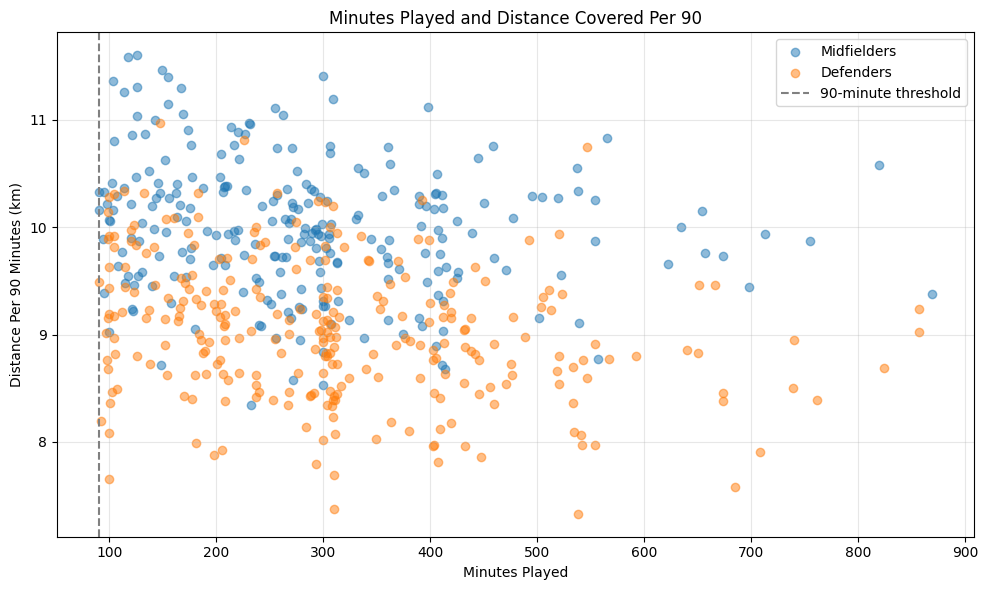

In [104]:
mf_population_task3 = task3_df[task3_df["Position"] == "MF"]
df_population_task3 = task3_df[task3_df["Position"] == "DF"]

plt.figure(figsize=(10, 6))

plt.scatter(
    mf_population_task3["MinutesPlayed"],
    mf_population_task3["DistancePer90"],
    label="Midfielders",
    alpha=0.5
)

plt.scatter(
    df_population_task3["MinutesPlayed"],
    df_population_task3["DistancePer90"],
    label="Defenders",
    alpha=0.5
)

plt.axvline(90, color="grey", linestyle="--", label="90-minute threshold")
plt.xlabel("Minutes Played")
plt.ylabel("Distance Per 90 Minutes (km)")
plt.title("Minutes Played and Distance Covered Per 90")
plt.legend()
plt.grid(
    alpha=0.3
)
plt.tight_layout()
plt.show()

In [ ]:
physical_df.to_csv("fifa_physical_all_players.csv", index=False)

task3_df.to_csv("task3_eligible_midfielders_defenders.csv", index=False)

task3_sample = pd.concat([mf_sample, df_sample])

task3_sample.to_csv("task1_random_sample.csv", index=False)

# References
Charles Darwin University, (2026a). Summary statistics [Course learning material]. Learnline.

Charles Darwin University, (2026b). HIT140 Week 4 learning material: Hypothesis testing [Course learning material]. Learnline.

Charles Darwin University, (2026c). Merging datasets[Course learning material]. Learnline.

Charles Darwin University, (2026d). Two-sample t-test [Course learning material]. Learnline.

Fédération Internationale de Football Association (2026a). FIFA World Cup 2026 player statistics. https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics?group=gcp_physical&stat=total_distance

Fédération Internationale de Football Association (2026b). FIFA World Cup 2026 player statistics.https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics?group=gcp_top_scorer&stat=total_competition_minutes_played

IPython Development Team. (n.d.). Built-in magic commands. IPython documentation. Retrieved September 9, 2026, from https://ipython.readthedocs.io/en/stable/interactive/magics.html

Matplotlib Development Team (n.d.-a). matplotlib.pyplot.errorbar. Matplotlib documentation. Retrieved September 9, 2026, from https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html

Matplotlib Development Team (n.d.-b). Different ways of specifying error bars. Matplotlib documentation. Retrieved September 9, 2026, from https://matplotlib.org/stable/gallery/statistics/errorbar_features.html

Matplotlib Development Team (n.d-c) Matplotlin API reference. Matplotlib documentation. Retrieved September 9, 2026, from https://matplotlib.org/stable/api/index.html

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt and J. Millman (Eds.), Proceedings of the 9th Python in Science Conference (pp.56-61). https://proceedings.scipy.org/articles/Majora-92bf1922-00a

Microsoft (n.d.-a). BrowserType. Playwright for Python. Retrieved September 9, 2026, from https://playwright.dev/python/docs/api/clas-browsertype#browser-type-launch

Microsoft. (n.d.-b). Evaluating Javascript. Playwright for Python. Retrieved September 9, 2026, from https://playwright.dev/python/docs/evaluating

Microsoft. (n.d.-c). Network. Playwright for Python. Retirieved September 9, 2026, from https://playwright.dev/python/docs/network

Microsoft. (n.d.-d). Installation. Playwright for Python. Retirieved September 9, 2026, from https://playwright.dev/python/docs/intro

Mozilla. (n.d.-a). encodeURIComponent(). MDN Web Docs. https://developer.mozilla.org/en-US/docs/Web/Javascript/Reference/Global_Objects/encodeURIComponent

National Institute of Standards and Technology. (2012). NIST/SEMATECH e-handbook of statistcal methods. https://www.itl.nist.gov/div898/handbook/

pandas Development Team. (n.d.-a). How to combine data from multiple tables. pandas documentation. Retrieved September 9,2026, from https://pandas.pydata.org/docs/getting_started/intro_tutorials/08_combine_dataframes.html

pandas Development Team. (n.d.-b). pandasDataFrame.sample. pandas documentation. Retrieved September 9,2026, from https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html

pandas Development Team. (n.d.-c). pandas API reference. Retrieved September 9,2026, from https://pandas.pydata.org/docs/reference/index.html

pandas development team. (n.d.-d). pandas.to_numeric. pandas documentation. Retrieved September 9, 2026, from https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html

pandas development team. (n.d.-e). How to create new columns derived from existing columns. pandas documentation. Retrieved September 9, 2026, from https://pandas.pydata.org/docs/getting_started/intro_tutorials/05_add_columns.html

Python Software Foundation. (n.d.-a). asyncio-Asynchronous I/O. Python documentation. Retrieved September 9, 2026, from https://docs.python.org/3/library/asyncio.html

Python Software Foundation. (n.d.-b). json-JSON encoder and decoder. Python 3 documentation. Retrieved September 9, 2026, from https://docs.python.org/3/library/json.html

Python Software Foundation. (n.d.-c). Date structures. Python 3 documentation. Retrieved September 9, 2026, from https://docs.python.org/3/tutorial/datastructures.html

Satterthwaite, F. E. (1946). An approximate distribution of estimates of variance components. Biometrics Bulletin, 2(6), 110-114.https://www.jstor.org/stable/3002019

SciPy Community. (n.d.). scipy.stats.ttest_ind. SciPy documentation. Retrieved September 9, 2026 from https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

Ubuntu Manpage Repository. (n.d). xvfb-run-Run specified X client or command in a virtual X server environment. Retrieved September 9, 2026, from https://manpages.ubuntu.com/manpages/noble/man1/xvfb-run.1.html

Welch, B. L. (1947). The generalization of "Student's" problem when several different population variances are involved. Biometrika, 34(1-2), 28-35 https://academic.oup.com/biomet/article-abstract/34/1-2/28/210174


